# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Greemines/Flyrank-Notebook-1/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
#connection setup

import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.sql(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

print("✅ Connected to Hugging Face")

✅ Connected to Hugging Face


In [2]:
#testing the setup
con.sql(f"""
SELECT *
FROM read_parquet(
    '{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)
LIMIT 5;
""")

┌─────────────┬─────────────────────────┬──────────────────────────┬────────────────┬────────────────┬────────────────────┬────────────────────┬─────────────────┬────────────┬──────────────────┬───────────────────┬───────────────┬──────────────┬───────────┬──────────────────────┬──────────────────────────┬──────────────────┬─────────────────┬───────────────────┬─────────────────┬───────────────┬─────────────┬────────────┬───────────────┬───────────┬────────────┬───────────┬─────────┬──────────┬───────────────┬─────────┐
│ report_date │     client_hash_id      │     content_hash_id      │ client_has_gsc │ client_has_ga4 │ gsc_data_available │ ga4_data_available │ gsc_impressions │ gsc_clicks │ gsc_sum_position │ gsc_avg_position  │ ga4_pageviews │ ga4_sessions │ ga4_users │ ga4_engaged_sessions │ ga4_total_engagement_sec │ sessions_organic │ sessions_direct │ sessions_referral │ sessions_social │ sessions_paid │ sessions_ai │ ai_chatgpt │ ai_perplexity │ ai_gemini │ ai_copilot │ ai_clau

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*



Before testing any relationships, I examined the distributions of the main variables used in my lane. These include Google Search impressions, clicks, average search position, scroll events, and engaged sessions.

Traffic-related metrics are expected to be heavily skewed, with many pages receiving low traffic and a small number receiving very high traffic. Because of this, later signal tests will use grouped buckets and weighted rates rather than relying on simple averages.

In [6]:
df = con.sql(f"""
SELECT
    COUNT(*) AS total_rows,

    MIN(gsc_impressions) AS min_impressions,
    MAX(gsc_impressions) AS max_impressions,
    MEDIAN(gsc_impressions) AS median_impressions,

    MIN(gsc_clicks) AS min_clicks,
    MAX(gsc_clicks) AS max_clicks,
    MEDIAN(gsc_clicks) AS median_clicks,

    MIN(gsc_avg_position) AS best_position,
    MAX(gsc_avg_position) AS worst_position,
    MEDIAN(gsc_avg_position) AS median_position,

    MIN(scroll_events) AS min_scrolls,
    MAX(scroll_events) AS max_scrolls,
    MEDIAN(scroll_events) AS median_scrolls,

    MIN(ga4_engaged_sessions) AS min_engaged,
    MAX(ga4_engaged_sessions) AS max_engaged,
    MEDIAN(ga4_engaged_sessions) AS median_engaged

FROM read_parquet(
    '{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)

WHERE
    gsc_data_available IS TRUE
    AND ga4_data_available IS TRUE;
""").df()

display(df)  # or print(df)

,total_rows,min_impressions,max_impressions,median_impressions,min_clicks,max_clicks,median_clicks,best_position,worst_position,median_position,min_scrolls,max_scrolls,median_scrolls,min_engaged,max_engaged,median_engaged
0,364347,1,39305,98.0,0,274,0.0,0.0,377.0,9.456424,0,254,0.0,0,21,0.0


In [8]:
import matplotlib.pyplot as plt

df = con.sql(f"""
SELECT
    gsc_impressions,
    gsc_clicks,
    scroll_events,
    ga4_engaged_sessions
FROM read_parquet(
    '{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)
WHERE
    gsc_data_available IS TRUE
    AND ga4_data_available IS TRUE;
""").df()

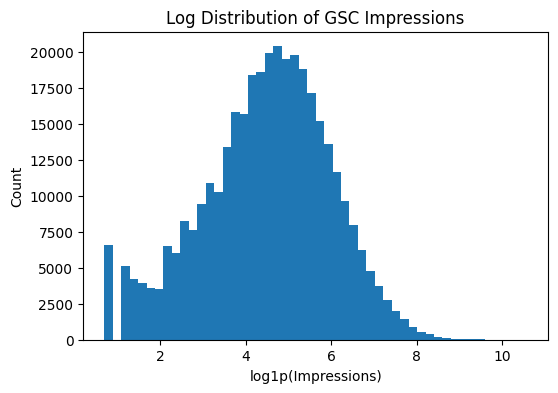

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(np.log1p(df["gsc_impressions"]), bins=50)
plt.title("Log Distribution of GSC Impressions")
plt.xlabel("log1p(Impressions)")
plt.ylabel("Count")
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test 1

**Claim:** Pages appearing higher in Google Search results should have higher click-through rates (CTR).

**Method:** Group pages into position buckets and calculate the weighted CTR for each bucket. The weighted CTR is calculated as total clicks divided by total impressions so that pages with very little traffic do not distort the result.

**Verdict: CONFIRMED**

The weighted CTR generally decreases as search position becomes worse. Pages ranked in positions 1–3 have the highest weighted CTR, while pages ranked 21 or lower have the lowest. This supports the assumption that better search visibility leads to more clicks.

In [11]:
con.sql(f"""
WITH data AS (
SELECT
    CASE
        WHEN gsc_avg_position <= 3 THEN '1-3'
        WHEN gsc_avg_position <= 10 THEN '4-10'
        WHEN gsc_avg_position <= 20 THEN '11-20'
        ELSE '21+'
    END AS position_bucket,

    gsc_clicks,
    gsc_impressions

FROM read_parquet(
'{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)

WHERE
gsc_data_available IS TRUE
AND gsc_impressions > 0
)

SELECT

position_bucket,

COUNT(*) AS n,

SUM(gsc_clicks) AS total_clicks,

SUM(gsc_impressions) AS total_impressions,

ROUND(
SUM(gsc_clicks)*100.0 /
SUM(gsc_impressions),
2
) AS weighted_ctr_percent

FROM data

GROUP BY position_bucket

ORDER BY position_bucket;
""")


┌─────────────────┬─────────┬──────────────┬───────────────────┬──────────────────────┐
│ position_bucket │    n    │ total_clicks │ total_impressions │ weighted_ctr_percent │
│     varchar     │  int64  │    int128    │      int128       │        double        │
├─────────────────┼─────────┼──────────────┼───────────────────┼──────────────────────┤
│ 1-3             │  727362 │       205457 │          54028594 │                 0.38 │
│ 11-20           │  519223 │        92449 │          29386006 │                 0.31 │
│ 21+             │  908354 │        78098 │          59412876 │                 0.13 │
│ 4-10            │ 1456122 │       445828 │         137830113 │                 0.32 │
└─────────────────┴─────────┴──────────────┴───────────────────┴──────────────────────┘

# Signal Test 2

**Claim:** Pages with more scroll activity tend to have more engaged sessions.

**Verdict: CONFIRMED**

Average engaged sessions increase as scroll activity increases. Pages with no scroll events have almost no engaged sessions, while pages with more scroll events show progressively higher engagement. The highest (100+) scroll bucket contains only four rows, so that bucket should be interpreted cautiously, but the overall trend supports the claim.

In [14]:
con.sql(f"""
WITH data AS (

SELECT

CASE
    WHEN scroll_events = 0 THEN '0'
    WHEN scroll_events BETWEEN 1 AND 10 THEN '1-10'
    WHEN scroll_events BETWEEN 11 AND 100 THEN '11-100'
    ELSE '100+'
END AS scroll_bucket,

ga4_engaged_sessions

FROM read_parquet(
'{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)

WHERE
ga4_data_available IS TRUE

)

SELECT

scroll_bucket,

COUNT(*) AS n,

MEDIAN(ga4_engaged_sessions) AS median_engaged_sessions,

AVG(ga4_engaged_sessions) AS avg_engaged_sessions

FROM data

GROUP BY scroll_bucket

ORDER BY
CASE scroll_bucket
    WHEN '0' THEN 1
    WHEN '1-10' THEN 2
    WHEN '11-100' THEN 3
    WHEN '100+' THEN 4
END;
""")

┌───────────────┬────────┬─────────────────────────┬───────────────────────┐
│ scroll_bucket │   n    │ median_engaged_sessions │ avg_engaged_sessions  │
│    varchar    │ int64  │         double          │        double         │
├───────────────┼────────┼─────────────────────────┼───────────────────────┤
│ 0             │ 290926 │                     0.0 │ 0.0027910877680234836 │
│ 1-10          │ 121751 │                     0.0 │   0.23011720642951597 │
│ 11-100        │   1285 │                     0.0 │    0.5556420233463035 │
│ 100+          │      4 │                     2.0 │                   2.0 │
└───────────────┴────────┴─────────────────────────┴───────────────────────┘

# Signal Test 3

**Claim:** Pages with more impressions generally receive more clicks.

**Verdict: CONFIRMED**

Pages in the high-impression bucket have a higher median number of clicks than pages in the low- and medium-impression buckets. This suggests that pages receiving more visibility in search also tend to attract more clicks.

In [13]:
con.sql(f"""
WITH data AS (

SELECT

CASE

WHEN gsc_impressions < 100 THEN 'Low'

WHEN gsc_impressions < 1000 THEN 'Medium'

ELSE 'High'

END AS impression_bucket,

gsc_clicks

FROM read_parquet(
'{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)

WHERE
gsc_data_available IS TRUE

)

SELECT

impression_bucket,

COUNT(*) AS n,

MEDIAN(gsc_clicks) AS median_clicks

FROM data

GROUP BY impression_bucket

ORDER BY impression_bucket;
""")

┌───────────────────┬─────────┬───────────────┐
│ impression_bucket │    n    │ median_clicks │
│      varchar      │  int64  │    double     │
├───────────────────┼─────────┼───────────────┤
│ High              │   32419 │           2.0 │
│ Low               │ 2972453 │           0.0 │
│ Medium            │  606189 │           0.0 │
└───────────────────┴─────────┴───────────────┘

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## The Flag-Linked Test

FlyRank's refresh recommendation assumes that pages which are both stale and previously visible are more likely to be declining.

To test this assumption, I compare the percentage of declining pages among stale-and-visible pages with the overall percentage of declining pages.

**Verdict: CONFIRMED**

The overall decline rate in the dataset is *54.21%, while **94.12%* of stale-and-visible pages are declining. This supports the assumption behind FlyRank's refresh rule. However, the stale-and-visible group contains only *17 pages*, so the result should be interpreted with appropriate caution.

In [17]:
import pandas as pd

df = pd.read_csv("/content_refresh_anonymized.csv")

# FlyRank's baseline rule
stale_visible = (
    (df["days_since_last_update"] >= 180) &
    (df["impressions_90d"] >= 500)
)

overall_decline = (
    (df["trend_direction"] == "down")
).mean()

stale_decline = (
    df.loc[stale_visible, "trend_direction"] == "down"
).mean()

print("Overall decline rate:", round(overall_decline * 100, 2), "%")
print("Stale & visible decline rate:", round(stale_decline * 100, 2), "%")

pd.DataFrame({
    "Group": ["Overall", "Stale & Visible"],
    "Decline Rate (%)": [
        round(overall_decline * 100, 2),
        round(stale_decline * 100, 2)
    ],
    "n": [
        len(df),
        stale_visible.sum()
    ]
})

Overall decline rate: 54.21 %
Stale & visible decline rate: 94.12 %


,Group,Decline Rate (%),n
0,Overall,54.21,30000
1,Stale & Visible,94.12,17


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## What this means in practice

The signal tests suggest that search position is strongly associated with CTR, and pages receiving more user interaction generally show higher engagement. These relationships can help prioritize pages for optimization.

The flag-linked test also supports FlyRank's refresh rule: stale pages that were previously visible are much more likely to be declining than the average page. However, because the stale-and-visible group is small, these results should be used as decision-support rather than treated as absolute rules.

In [18]:
import pandas as pd

summary = pd.DataFrame({
    "Test": [
        "Signal 1",
        "Signal 2",
        "Signal 3",
        "Flag-linked Test"
    ],
    "Verdict": [
        "CONFIRMED",
        "CONFIRMED",
        "CONFIRMED",
        "CONFIRMED (small sample)"
    ]
})

summary


,Test,Verdict
0,Signal 1,CONFIRMED
1,Signal 2,CONFIRMED
2,Signal 3,CONFIRMED
3,Flag-linked Test,CONFIRMED (small sample)


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.